In [ ]:
# Real Ecosystem Audits (NLP + Vision)
# Motivation
# Real ecosystems expose architecture-specific and intervention-specific substitution gaps that may not appear in synthetic tests. This notebook jointly analyzes NLP masking audits and CV adversarial-dose audits under a unified Kernel-PIER lens.  

# $$
# U_t^{\mathrm{ker}}(\Lambda)=\mathbb{E}[|Y_t-h^*_{\Lambda}(\Phi_{-t})|],\quad
# \Delta_t(\Lambda)=U_t^{\mathrm{conv}}-U_t^{\mathrm{ker}}(\Lambda).
# $$

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 12,
    "axes.labelsize": 14,
    "axes.titlesize": 14,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
    "legend.frameon": False,
    "figure.figsize": (7, 4.5),
    "figure.dpi": 150,
    "mathtext.fontset": "dejavuserif"
})

from pathlib import Path
import numpy as np
import pandas as pd
art_dir = Path('../results/artifacts').resolve()
art_dir.mkdir(parents=True, exist_ok=True)

df3a = pd.read_csv(Path('../results/tables/exp3a_bert_kernel.csv').resolve())
df3b = pd.read_csv(Path('../results/tables/exp3b_imagenet_kernel.csv').resolve())
df3a.head(), df3b.head()

(                         target_model    target_group  theta  lambda  \
 0  Architectural Divergence (RoBERTa)  Low Redundancy    0.5   0.100   
 1  Architectural Divergence (RoBERTa)  Low Redundancy    0.5   0.030   
 2  Architectural Divergence (RoBERTa)  Low Redundancy    0.5   0.010   
 3  Architectural Divergence (RoBERTa)  Low Redundancy    0.5   0.003   
 4  Architectural Divergence (RoBERTa)  Low Redundancy    0.5   0.001   
 
         budget  convex_fit_distance  convex_pier  kernel_pier  pier_drop  \
 0    10.000000             1.195791     0.121482     0.103776   0.017706   
 1    33.333333             1.195791     0.121482     0.107538   0.013944   
 2   100.000000             1.195791     0.121482     0.121233   0.000249   
 3   333.333333             1.195791     0.121482     0.146135  -0.024653   
 4  1000.000000             1.195791     0.121482     0.176188  -0.054707   
 
    pier_drop_ratio  num_peers  n_fit  n_eval  honesty_fit_size  \
 0         0.145747          

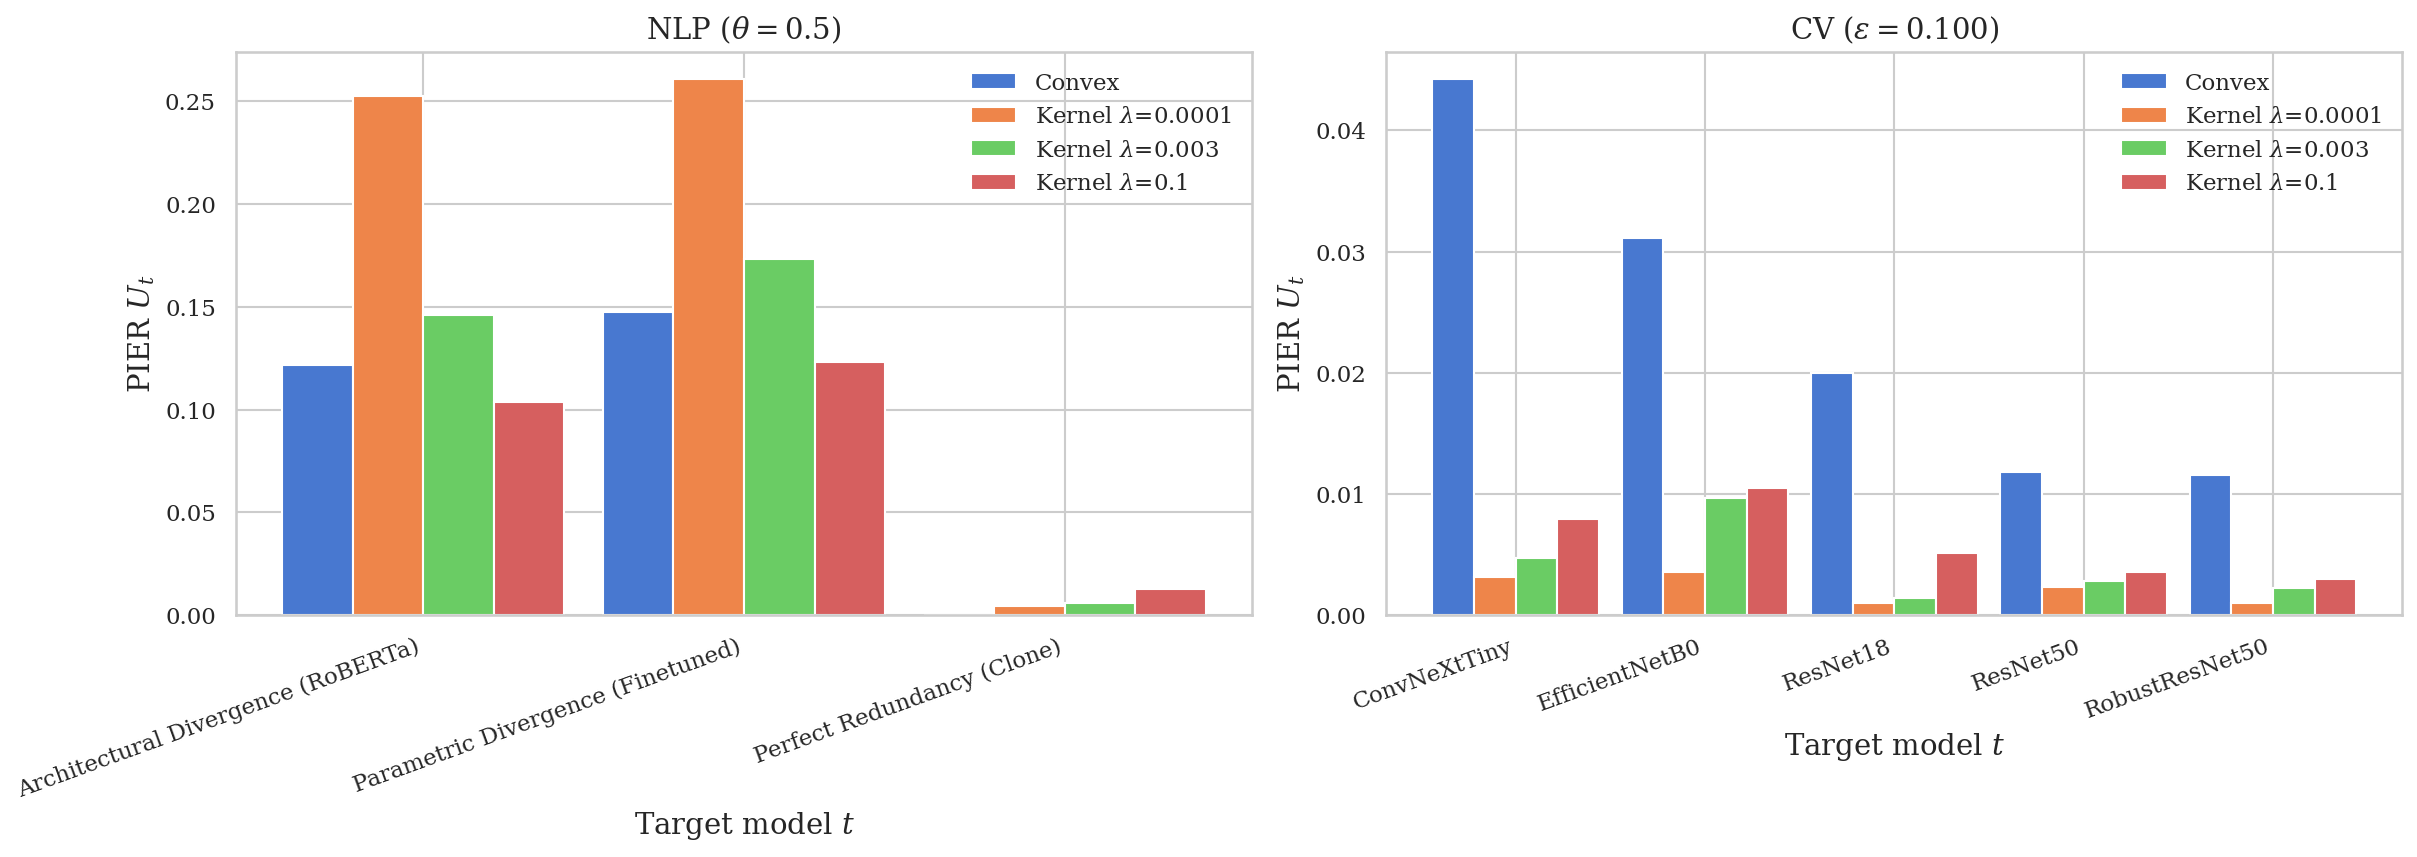

In [ ]:
### Main cross-ecosystem comparison at matched budgets
# This is the headline figure: Convex baseline vs multiple kernel budgets across targets in NLP and CV.

lambda_show = sorted(set(df3a['lambda']).intersection(set(df3b['lambda'])))
if len(lambda_show) >= 3:
    lambda_show = [lambda_show[0], lambda_show[len(lambda_show)//2], lambda_show[-1]]

nlp = df3a[df3a['lambda'].isin(lambda_show)].groupby(['target_model', 'lambda'], as_index=False).agg(convex=('convex_pier', 'mean'), kernel=('kernel_pier', 'mean'))
cv_eps = float(df3b['dose_epsilon'].max())
cv = df3b[(df3b['lambda'].isin(lambda_show)) & (np.isclose(df3b['dose_epsilon'], cv_eps))].groupby(['target_model', 'lambda'], as_index=False).agg(convex=('convex_pier', 'mean'), kernel=('kernel_pier', 'mean'))

fig, axes = plt.subplots(1, 2, figsize=(16, 5.6), constrained_layout=True)
for ax, data, title in [(axes[0], nlp, r'NLP ($\theta=0.5$)'), (axes[1], cv, rf'CV ($\epsilon={cv_eps:.3f}$)')]:
    models = sorted(data['target_model'].unique())
    x = np.arange(len(models))
    w = 0.22
    conv = data.groupby('target_model')['convex'].mean().reindex(models).values
    ax.bar(x - 1.5*w, conv, width=w, label='Convex')
    for i, lam in enumerate(lambda_show):
        vals = data[data['lambda'] == lam].set_index('target_model').reindex(models)['kernel'].values
        ax.bar(x + (-0.5 + i)*w, vals, width=w, label=rf'Kernel $\lambda$={lam:g}')
    ax.set_xticks(x)
    ax.set_xticklabels(models, rotation=20, ha='right')
    ax.set_xlabel(r'Target model $t$')
    ax.set_ylabel(r'PIER $U_t$')
    ax.set_title(title)
    ax.legend(loc='best')

plt.savefig(art_dir / 'exp3_main_cross_ecosystem_bars.pdf', format='pdf', bbox_inches='tight')
plt.show()

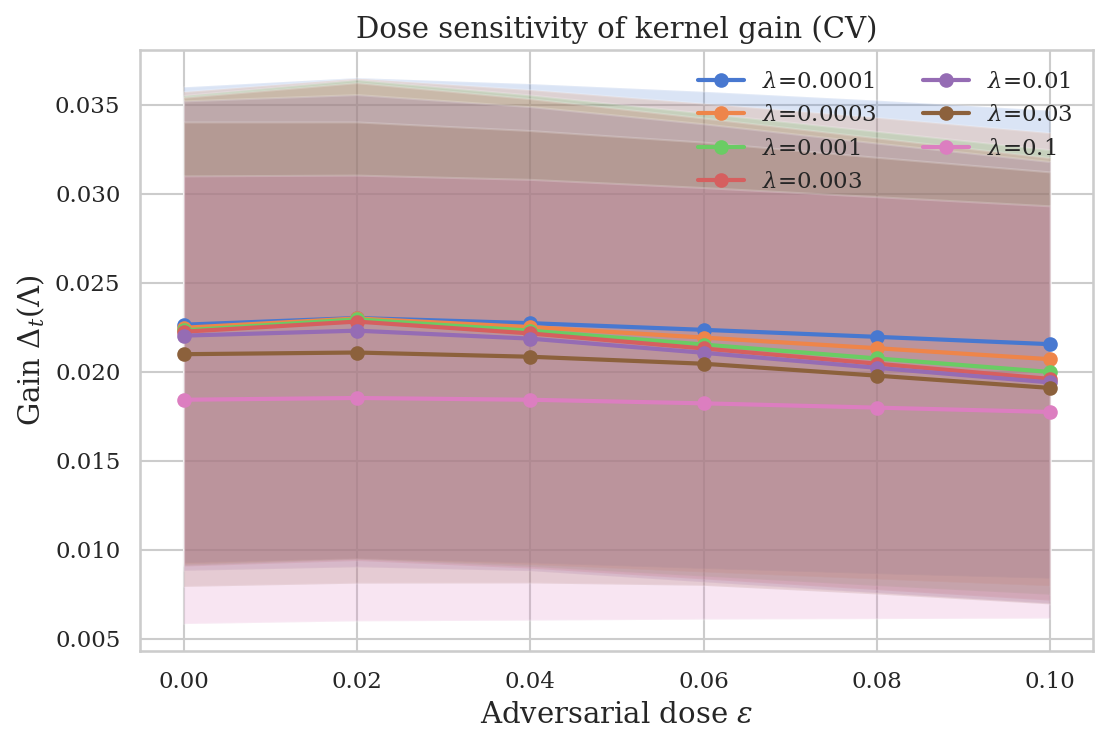

In [ ]:

# Dose sensitivity in CV (intervention strength)
# We care whether kernel gain is robust as intervention dose increases. We track average gain vs $\epsilon$ per budget.

cv_gain = df3b.copy()
cv_gain['gain'] = cv_gain['convex_pier'] - cv_gain['kernel_pier']
agg = cv_gain.groupby(['dose_epsilon', 'lambda'], as_index=False).agg(mu=('gain', 'mean'), sd=('gain', 'std'))

fig, ax = plt.subplots(figsize=(8.2, 5.2))
for lam, sub in agg.groupby('lambda'):
    sub = sub.sort_values('dose_epsilon')
    x = sub['dose_epsilon'].to_numpy()
    y = sub['mu'].to_numpy()
    s = sub['sd'].fillna(0.0).to_numpy()
    ax.plot(x, y, marker='o', linewidth=2.0, label=rf'$\lambda$={lam:g}')
    ax.fill_between(x, y - s, y + s, alpha=0.2)
ax.set_xlabel(r'Adversarial dose $\epsilon$')
ax.set_ylabel(r'Gain $\Delta_t(\Lambda)$')
ax.set_title('Dose sensitivity of kernel gain (CV)')
ax.legend(loc='best', ncol=2)
plt.savefig(art_dir / 'exp3_dose_sensitivity_analysis.pdf', format='pdf', bbox_inches='tight')
plt.show()

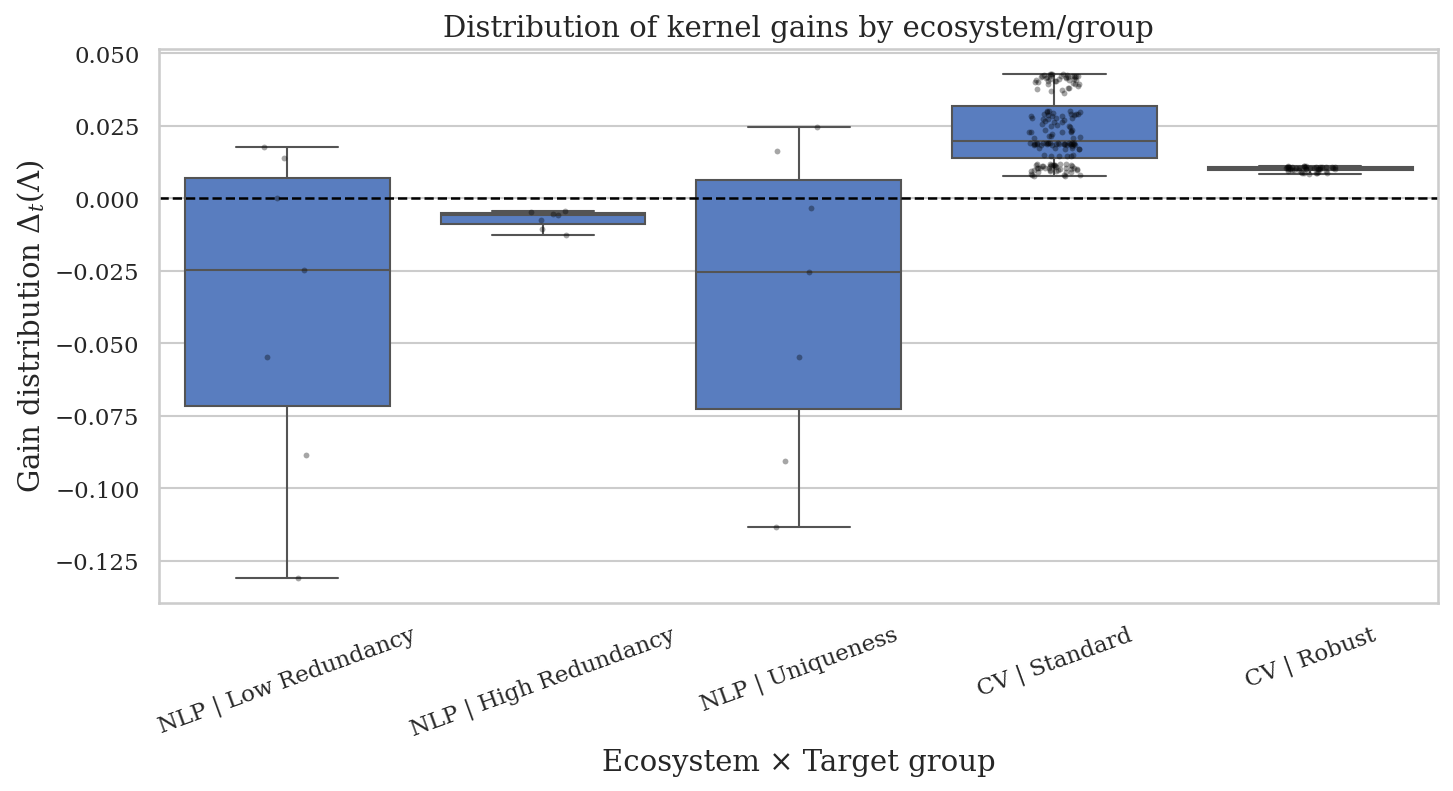

In [ ]:
# Distributional perspective across target groups
# A box+strip diagnostic shows whether gains concentrate in a few models or are broadly distributed.

a = df3a[['target_group', 'pier_drop']].copy()
a['ecosystem'] = 'NLP'
b = df3b[['target_group', 'pier_drop']].copy()
b['ecosystem'] = 'CV'
mix = pd.concat([a, b], ignore_index=True)
mix['panel'] = mix['ecosystem'] + ' | ' + mix['target_group'].astype(str)

fig, ax = plt.subplots(figsize=(11, 4.8))
sns.boxplot(data=mix, x='panel', y='pier_drop', ax=ax)
sns.stripplot(data=mix, x='panel', y='pier_drop', color='black', alpha=0.35, size=2.8, ax=ax)
ax.axhline(0.0, linestyle='--', color='black', linewidth=1.2)
ax.set_xlabel('Ecosystem × Target group')
ax.set_ylabel(r'Gain distribution $\Delta_t(\Lambda)$')
ax.set_title('Distribution of kernel gains by ecosystem/group')
ax.tick_params(axis='x', rotation=20)
plt.savefig(art_dir / 'exp3_gain_distribution_box_strip.pdf', format='pdf', bbox_inches='tight')
plt.show()

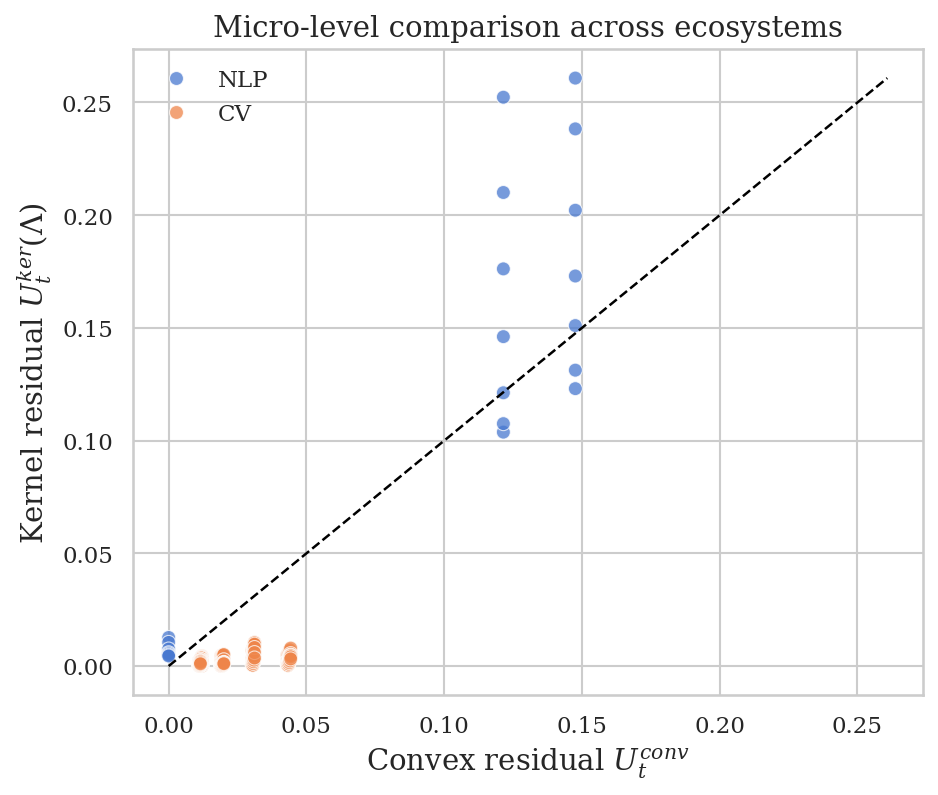

In [ ]:
# Micro-level failure/win map vs diagonal
# Scatter against $y=x$ provides direct sample-level evidence of where kernel routing dominates or fails.

sc_nlp = df3a[['convex_pier', 'kernel_pier']].copy()
sc_nlp['ecosystem'] = 'NLP'
sc_cv = df3b[['convex_pier', 'kernel_pier']].copy()
sc_cv['ecosystem'] = 'CV'
sc = pd.concat([sc_nlp, sc_cv], ignore_index=True)

fig, ax = plt.subplots(figsize=(6.8, 5.6))
sns.scatterplot(data=sc, x='convex_pier', y='kernel_pier', hue='ecosystem', s=45, alpha=0.75, ax=ax)
mn = min(sc['convex_pier'].min(), sc['kernel_pier'].min())
mx = max(sc['convex_pier'].max(), sc['kernel_pier'].max())
ax.plot([mn, mx], [mn, mx], linestyle='--', color='black', linewidth=1.2)
ax.set_xlabel(r'Convex residual $U_t^{conv}$')
ax.set_ylabel(r'Kernel residual $U_t^{ker}(\Lambda)$')
ax.set_title('Micro-level comparison across ecosystems')
ax.legend(loc='best')
plt.savefig(art_dir / 'exp3_micro_scatter_convex_vs_kernel.pdf', format='pdf', bbox_inches='tight')
plt.show()